In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [5]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [4]:
df["Review Rating"] = df.groupby("Category")["Review Rating"].transform(
    lambda x: x.fillna(x.median())
)

In [6]:
y = df["Subscription Status"]

In [7]:
X = df.drop("Subscription Status", axis=1)

In [8]:
X = X.drop("Customer ID", axis=1)

In [9]:
label_encoder = LabelEncoder()

for column in X.select_dtypes(include="object").columns:
    X[column] = label_encoder.fit_transform(X[column])

y = label_encoder.fit_transform(y)

In [10]:
X.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,1,2,1,53,16,0,7,3,3.1,1,1,1,14,5,3
1,19,1,23,1,64,18,0,12,3,3.1,1,1,1,2,1,3
2,50,1,11,1,73,20,2,12,1,3.1,2,1,1,23,2,6
3,21,1,14,2,90,38,1,12,1,3.5,3,1,1,49,4,6
4,45,1,2,1,49,36,1,21,1,2.7,2,1,1,31,4,0


In [11]:
y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)
print(X_test.shape)

(3120, 16)
(780, 16)


In [14]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
dt_predictions = decision_tree.predict(X_test)

In [16]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", round(dt_accuracy, 4))

Decision Tree Accuracy: 0.7987


In [17]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       558
           1       0.64      0.67      0.65       222

    accuracy                           0.80       780
   macro avg       0.75      0.76      0.76       780
weighted avg       0.80      0.80      0.80       780



In [18]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
rf_predictions = random_forest.predict(X_test)


In [20]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy,4))

Random Forest Accuracy: 0.8167


In [21]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86       558
           1       0.62      0.90      0.74       222

    accuracy                           0.82       780
   macro avg       0.79      0.84      0.80       780
weighted avg       0.86      0.82      0.82       780



In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.798718
1,Random Forest,0.816667


In [23]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

best_model

,Model,Accuracy
1,Random Forest,0.816667
0,Decision Tree,0.798718


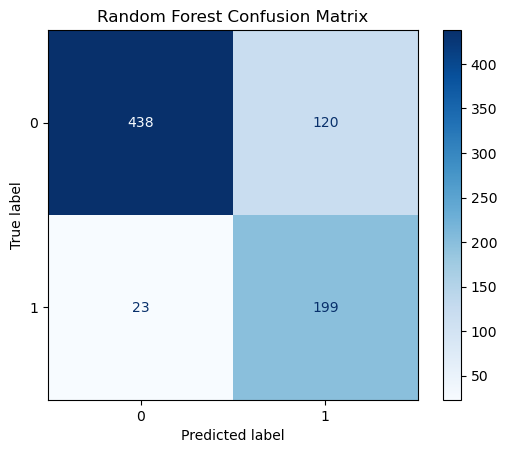

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,Discount Applied,0.234929
12,Promo Code Used,0.215233
0,Age,0.056700
13,Previous Purchases,0.056345
4,Purchase Amount (USD),0.056224
5,Location,0.053273
9,Review Rating,0.049213
2,Item Purchased,0.045706
7,Color,0.045631
1,Gender,0.042287


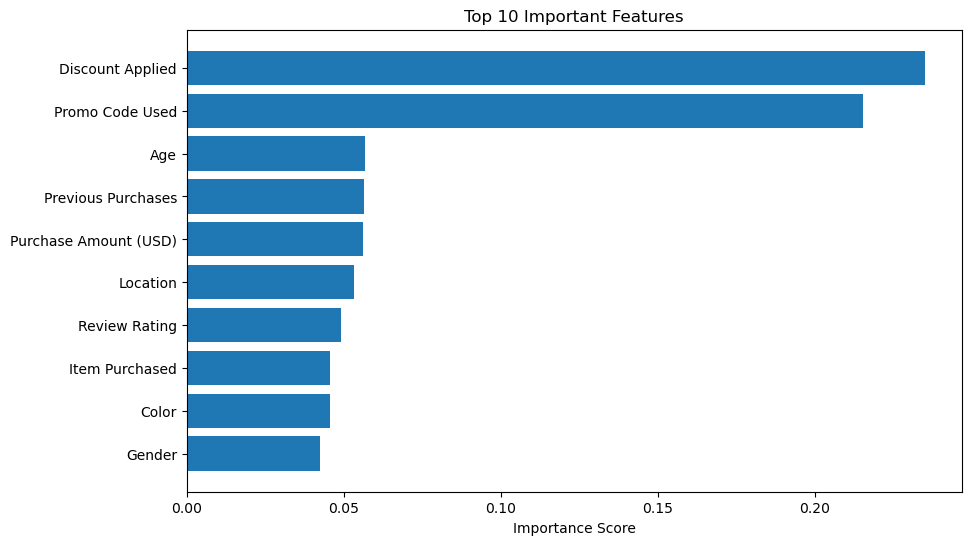

In [26]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.show()

In [27]:
import joblib

joblib.dump(
    random_forest,
    "subscription_prediction_model.pkl"
)


['subscription_prediction_model.pkl']

In [28]:
predictions = X_test.copy()

predictions["Actual"] = y_test

predictions["Predicted"] = rf_predictions

predictions.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Actual,Predicted
839,48,1,16,1,31,12,0,20,1,2.6,2,1,1,10,3,2,1,1
1717,29,1,9,1,50,10,0,14,2,2.9,1,0,0,16,3,1,0,0
321,41,1,20,2,36,44,0,14,2,4.7,2,1,1,48,3,5,1,1
3187,67,0,2,1,72,42,0,9,3,3.2,2,0,0,28,3,6,0,0
2269,49,1,19,1,38,16,1,24,0,4.4,5,0,0,27,2,0,0,0


In [29]:
comparison

,Model,Accuracy
0,Decision Tree,0.798718
1,Random Forest,0.816667


In [30]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86       558
           1       0.62      0.90      0.74       222

    accuracy                           0.82       780
   macro avg       0.79      0.84      0.80       780
weighted avg       0.86      0.82      0.82       780



In [31]:
from sklearn.metrics import roc_auc_score

rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

roc_score = roc_auc_score(y_test, rf_probabilities)

print("ROC-AUC Score:", round(roc_score, 4))

ROC-AUC Score: 0.8866


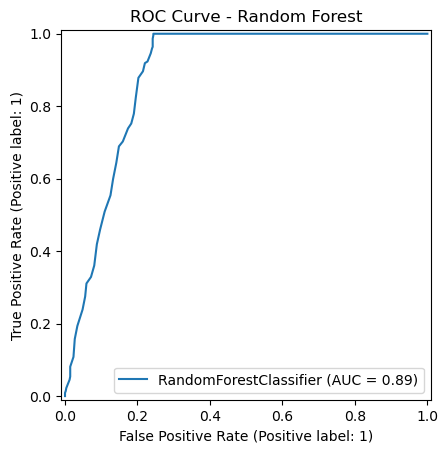

In [32]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    random_forest,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()